In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

dossier = '/content/drive/MyDrive/unet_deeplab_fcn'
print(os.path.exists(dossier))  # doit afficher True

# Voir ce qu il y a dedans
print(os.listdir(dossier)[:5])

True
['71037', '71029', '71038', '71040', '71033']


In [ ]:
# On travaille sur l'approche intermédiaire = segmentation par U-Net donc on travaille avec dossier: unet_deeplab_fcn => images 512×512 + entraînement meilleur ms lent

import pandas as pd
from pathlib import Path

# 1. Charger le fichier Excel
df = pd.read_csv('df_final.csv')
print(df.head())

# 2. Parcourir les images et créer le mapping
image_dir = Path("/content/drive/MyDrive/unet_deeplab_fcn")

records = []

for serialno_folder in sorted(image_dir.iterdir()):
    if not serialno_folder.is_dir():
        continue

    serialno = int(serialno_folder.name.split('_')[0])  # ex: 70025 (le split car y a des dossiers comme70025_Del)=> rq: on les a supprimé après

    for otolithe_folder in sorted(serialno_folder.iterdir()):
        if not otolithe_folder.is_dir():
            continue

        # Extraire l'âge depuis le nom du dossier ex: Nr01_age04 → 4
        folder_name = otolithe_folder.name  # "Nr01_age04"
        age = int(folder_name.split('_age')[1])  # → 4
        nr = folder_name.split('_')[0]            # → "Nr01"

        # Chemins des 2 images
        img_0 = otolithe_folder / 'image_0deg.png'
        img_180 = otolithe_folder / 'image_180deg.png'

        records.append({'serialno': serialno,'nr': nr,'age_from_folder': age,'img_0deg': str(img_0),'img_180deg': str(img_180)})

df_images = pd.DataFrame(records)
print(f"Nombre d'images trouvées : {len(df_images)}")
print(df_images.head(10))

   serialno    weight    length  age  sex  stage  liverweight  gonadweight  \
0     70029 -0.554135 -0.282389  6.0    2      1    -0.642656    -0.611509   
1     70029 -0.905812 -1.108129  3.0    1      1    -0.751148    -0.610037   
2     70029 -0.856653 -0.911525  4.0    2      1    -0.757344    -0.611509   
3     70029 -1.054802 -2.248438  1.0    0      1    -0.612892    -0.336299   
4     70029 -1.009172 -1.658623  3.0    1      1    -0.702568    -0.336299   

   spawningage  spawningzones  readability  otolithedge  otolithtype_2  \
0    -0.191298      -0.536424     1.365130            4              0   
1    -1.528887      -0.536424    -0.438642            4              0   
2    -1.083024      -0.536424    -0.438642            4              0   
3     0.214507      -0.536424    -0.438642            4              0   
4    -1.528887      -0.536424    -0.438642            4              0   

   otolithtype_4  otolithtype_5  
0              0              1  
1              0  

In [4]:
# 3. Fusionner avec les métadonnées Excel
df_final = df_images.merge(df, on='serialno', how='left')

print(f"\nAprès fusion : {len(df_final)} lignes")
print(df_final.columns.tolist())
print(df_final.head())

# 4. Vérification rapide
print("\n Vérification")
print(f"Âges uniques dans les dossiers : {sorted(df_final['age_from_folder'].unique())}")
print(f"Valeurs manquantes : {df_final.isnull().sum().sum()}")


Après fusion : 20425 lignes
['serialno', 'nr', 'age_from_folder', 'img_0deg', 'img_180deg', 'weight', 'length', 'age', 'sex', 'stage', 'liverweight', 'gonadweight', 'spawningage', 'spawningzones', 'readability', 'otolithedge', 'otolithtype_2', 'otolithtype_4', 'otolithtype_5']
   serialno    nr  age_from_folder  \
0     70025  Nr01                4   
1     70025  Nr01                4   
2     70025  Nr01                4   
3     70025  Nr01                4   
4     70025  Nr01                4   

                                            img_0deg  \
0  /content/drive/MyDrive/unet_deeplab_fcn/70025/...   
1  /content/drive/MyDrive/unet_deeplab_fcn/70025/...   
2  /content/drive/MyDrive/unet_deeplab_fcn/70025/...   
3  /content/drive/MyDrive/unet_deeplab_fcn/70025/...   
4  /content/drive/MyDrive/unet_deeplab_fcn/70025/...   

                                          img_180deg    weight    length  age  \
0  /content/drive/MyDrive/unet_deeplab_fcn/70025/... -0.912114 -1.029487  

In [5]:
# 5. Sauvegarder le mapping final
df_final.to_csv("mapping_images_metadata_approche2.csv", index=False)

In [ ]:
import pandas as pd
import numpy as np
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
from pathlib import Path

class OtolithDataset(Dataset):

    def __init__(self, df, img_size=(512, 512)):
        self.df = df.reset_index(drop=True)
        self.img_size = img_size

    def __len__(self):
        # Combien d'images on a au total
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # 1. Charger l'image brute (entrée du modèle)
        img = cv2.imread(row['img_0deg'], cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, self.img_size)

        # Normaliser entre 0 et 1
        img = img.astype(np.float32) / 255.0

        # Ajouter dimension canal : (512,512) => (1,512,512)
        img_tensor = torch.tensor(img).unsqueeze(0)

        # 2. Récupérer l'âge réel (ce que le modèle doit apprendre)
        age = torch.tensor(row['age_from_folder'], dtype=torch.float32)

        return img_tensor, age

In [ ]:
# Tester que le Dataset fonctionne

# Charger le CSV de mapping
df_mapping = pd.read_csv('mapping_images_metadata_approche2.csv')
df_mapping = df_mapping.sample(frac=0.2, random_state=42) #je travaille sur 20% des données
print(f"Nombre total d'otolithes : {len(df_mapping)}")

# Créer le dataset
dataset = OtolithDataset(df_mapping, img_size=(512, 512))

# Tester sur le premier élément
img, age = dataset[0]
print(f"Taille image : {img.shape}")  
print(f"Âge correspondant : {age}")    

Nombre total d'otolithes : 4085
Taille image : torch.Size([1, 512, 512])
Âge correspondant : 9.0


In [8]:
# Diviser en train / validation / test
from sklearn.model_selection import train_test_split

# 70% entraînement, 15% validation, 15% test
df_train, df_temp = train_test_split(df_mapping, test_size=0.30, random_state=42)
df_val, df_test   = train_test_split(df_temp,    test_size=0.50, random_state=42)

print(f"Train      : {len(df_train)} images")
print(f"Validation : {len(df_val)} images")
print(f"Test       : {len(df_test)} images")

# Créer les 3 datasets
train_dataset = OtolithDataset(df_train)
val_dataset   = OtolithDataset(df_val)
test_dataset  = OtolithDataset(df_test)

# Créer les DataLoaders (chargent les images par batch)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=8, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=8, shuffle=False)

print(f"Nombre de batches train : {len(train_loader)}")

Train      : 2859 images
Validation : 613 images
Test       : 613 images
Nombre de batches train : 358


In [9]:
!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 12.1 MB/s eta 0:00:00


In [10]:
import segmentation_models_pytorch as smp
import torch

# Charger U-Net avec backbone ResNet34 pré-entraîné
model = smp.Unet(
    encoder_name="resnet34",      # cerveau du modèle, pré-entraîné sur ImageNet
    encoder_weights="imagenet",   # poids pré-entraînés → apprend plus vite
    in_channels=1,                # 1 car tes images sont en niveaux de gris
    classes=1,                    # 1 car segmentation binaire : strie ou pas strie
    activation="sigmoid"          # sortie entre 0 et 1
)

# Vérifier que ça fonctionne
print("✅ Modèle U-Net chargé !")
print(f"Nombre de paramètres : {sum(p.numel() for p in model.parameters()):,}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

✅ Modèle U-Net chargé !
Nombre de paramètres : 24,430,097


In [11]:
# Simuler une image pour tester
image_test = torch.randn(1, 1, 512, 512)  # batch=1, canal=1, 512x512

# Passer l'image dans le modèle
with torch.no_grad():
    output = model(image_test)

print(f"Taille entrée  : {image_test.shape}")   # torch.Size([1, 1, 512, 512])
print(f"Taille sortie  : {output.shape}")        # torch.Size([1, 1, 512, 512])
print(f"Valeurs min/max : {output.min():.3f} / {output.max():.3f}")  # entre 0 et 1
print("✅ U-Net fonctionne correctement !")

Taille entrée  : torch.Size([1, 1, 512, 512])
Taille sortie  : torch.Size([1, 1, 512, 512])
Valeurs min/max : 0.002 / 0.998
✅ U-Net fonctionne correctement !


In [12]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
import segmentation_models_pytorch as smp

# Loss adaptée à la segmentation binaire
# DiceLoss gère bien les images où les stries sont peu nombreuses
dice_loss = smp.losses.DiceLoss(mode='binary')
bce_loss  = nn.BCELoss()

def total_loss(pred, target):
    return dice_loss(pred, target) + bce_loss(pred, target)

# Optimiseur
optimizer = Adam(model.parameters(), lr=1e-4)

# Réduit le learning rate si la loss ne s'améliore plus
scheduler = ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

print("✅ Loss et optimiseur prêts !")

✅ Loss et optimiseur prêts !


In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Charger le mapping
df_mapping = pd.read_csv('mapping_images_metadata_approche2.csv')
df_mapping = df_mapping.sample(frac=0.2, random_state=42) #je travaille sur 20% des données

# Diviser en train / validation / test
df_train, df_temp = train_test_split(df_mapping, test_size=0.30, random_state=42)
df_val,   df_test = train_test_split(df_temp,    test_size=0.50, random_state=42)

print(f"Train      : {len(df_train)} images")
print(f"Validation : {len(df_val)} images")
print(f"Test       : {len(df_test)} images")

# Créer les datasets
train_dataset = OtolithDataset(df_train, img_size=(512, 512))
val_dataset   = OtolithDataset(df_val,   img_size=(512, 512))
test_dataset  = OtolithDataset(df_test,  img_size=(512, 512))

# Créer les DataLoaders
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=4, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=4, shuffle=False)

print("✅ DataLoaders prêts !")

Train      : 2859 images
Validation : 613 images
Test       : 613 images
✅ DataLoaders prêts !


In [ ]:
# Utiliser GPU si disponible sur Colab
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Appareil utilisé : {device}")

model = model.to(device)

# ** Boucle d'entraînement **
NUM_EPOCHS = 40
best_val_loss = float('inf')

train_losses = []
val_losses   = []

for epoch in range(NUM_EPOCHS):

    # ** Phase entraînement **
    model.train()
    train_loss = 0

    for imgs, ages in train_loader:
        imgs = imgs.to(device)

        # Créer un masque cible à partir de l'image elle-même
        # (l'image binarisée EST le masque)
        targets = imgs.clone()

        # Prédiction du modèle
        preds = model(imgs)

        # Calculer la loss
        loss = total_loss(preds, targets)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    # ** Phase validation **
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for imgs, ages in val_loader:
            imgs    = imgs.to(device)
            targets = imgs.clone()
            preds   = model(imgs)
            loss    = total_loss(preds, targets)
            val_loss += loss.item()

    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    # Ajuster le learning rate
    scheduler.step(val_loss)

    # Sauvegarder le meilleur modèle
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), '/content/drive/MyDrive/best_unet_otolithes.pth')
        print(f"Epoch {epoch+1:02d} ✅ Meilleur modèle sauvegardé ! train_loss={train_loss:.4f} val_loss={val_loss:.4f}")
    else:
        print(f"Epoch {epoch+1:02d}    train_loss={train_loss:.4f}  val_loss={val_loss:.4f}")

print("\n✅ Entraînement terminé !")

Appareil utilisé : cuda
Epoch 01 ✅ Meilleur modèle sauvegardé ! train_loss=0.8672 val_loss=0.8500
Epoch 02 ✅ Meilleur modèle sauvegardé ! train_loss=0.8517 val_loss=0.8494
Epoch 03    train_loss=0.8511  val_loss=0.8497
Epoch 04 ✅ Meilleur modèle sauvegardé ! train_loss=0.8511 val_loss=0.8489
Epoch 05 ✅ Meilleur modèle sauvegardé ! train_loss=0.8505 val_loss=0.8489
Epoch 06    train_loss=0.8503  val_loss=0.8489
Epoch 07 ✅ Meilleur modèle sauvegardé ! train_loss=0.8504 val_loss=0.8488
Epoch 08    train_loss=0.8504  val_loss=0.8492
Epoch 09 ✅ Meilleur modèle sauvegardé ! train_loss=0.8505 val_loss=0.8488
Epoch 10 ✅ Meilleur modèle sauvegardé ! train_loss=0.8505 val_loss=0.8488
Epoch 11    train_loss=0.8501  val_loss=0.8488
Epoch 12 ✅ Meilleur modèle sauvegardé ! train_loss=0.8500 val_loss=0.8487
Epoch 13 ✅ Meilleur modèle sauvegardé ! train_loss=0.8499 val_loss=0.8487
Epoch 14 ✅ Meilleur modèle sauvegardé ! train_loss=0.8499 val_loss=0.8487
Epoch 15 ✅ Meilleur modèle sauvegardé ! train_lo

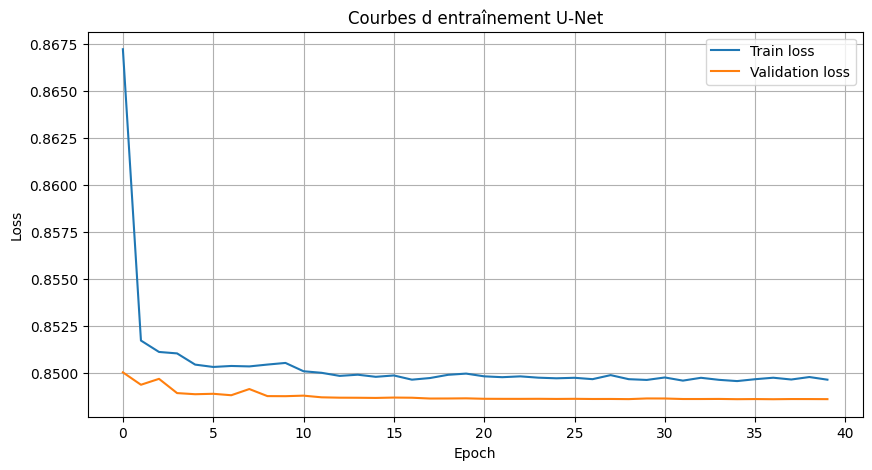

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train loss')
plt.plot(val_losses,   label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Courbes d entraînement U-Net')
plt.legend()
plt.grid(True)
plt.show()

**Evaluation sur test**

In [16]:
from sklearn.metrics import mean_absolute_error
import numpy as np

model.eval()
iou_scores  = []
dice_scores = []

with torch.no_grad():
    for imgs, ages in test_loader:
        imgs    = imgs.to(device)
        targets = imgs.clone()
        preds   = model(imgs)

        # Convertir en binaire (0 ou 1)
        preds_bin   = (preds > 0.5).float()
        targets_bin = (targets > 0.5).float()

        # Calculer IoU et Dice pour chaque image du batch
        for p, t in zip(preds_bin, targets_bin):
            intersection = (p * t).sum().item()
            union        = (p + t).clamp(0, 1).sum().item()
            iou  = intersection / (union + 1e-8)
            dice = 2 * intersection / (p.sum().item() + t.sum().item() + 1e-8)
            iou_scores.append(iou)
            dice_scores.append(dice)

print(f"IoU  moyen  : {np.mean(iou_scores):.4f}")
print(f"Dice moyen  : {np.mean(dice_scores):.4f}")

IoU  moyen  : 0.8506
Dice moyen  : 0.9184


**Visualisation : image brute vs masque prédit**


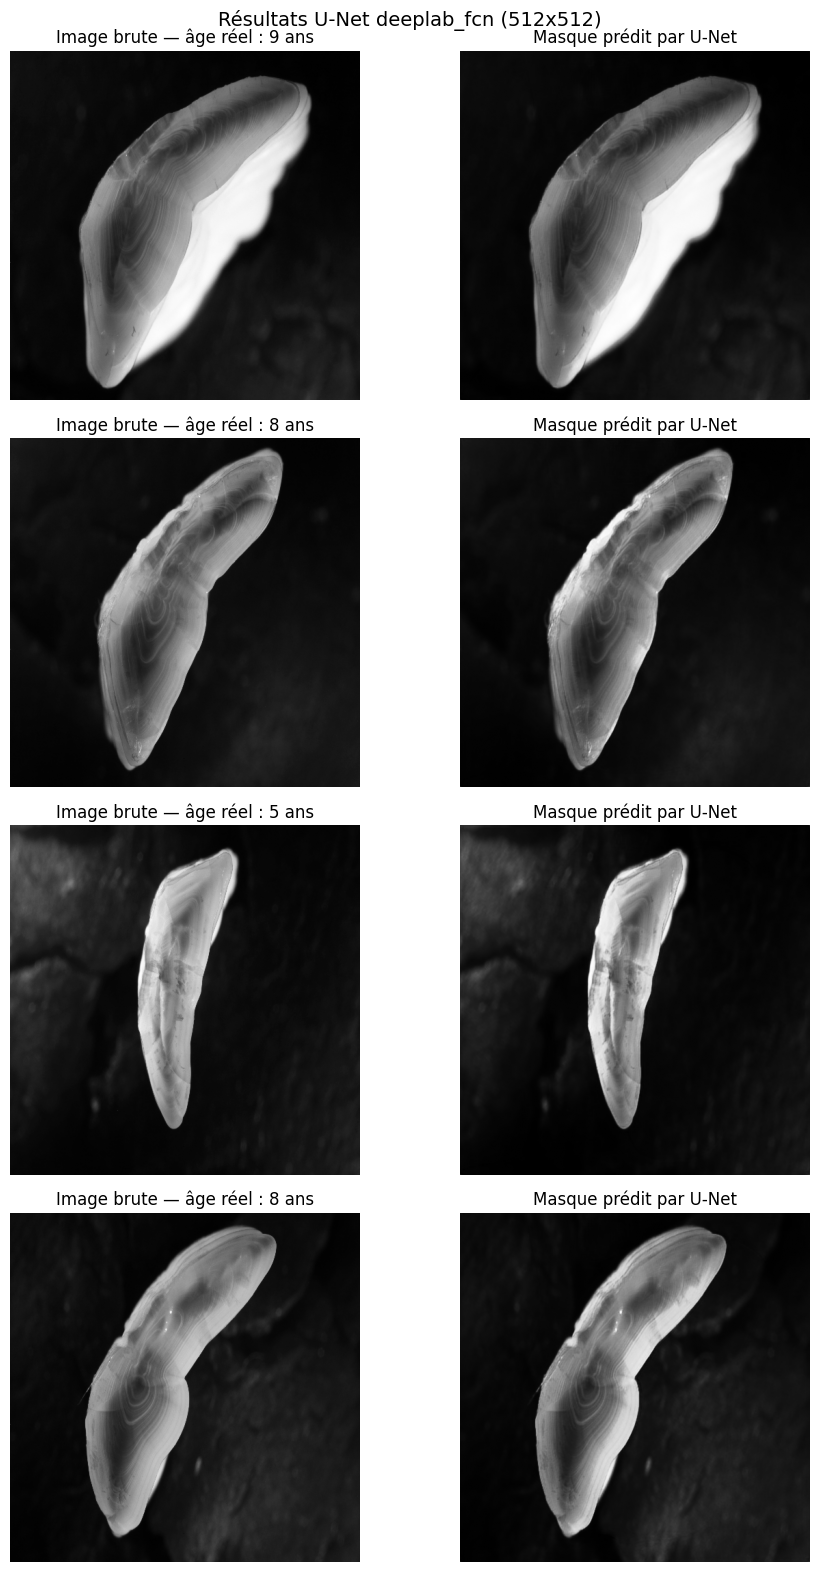

In [17]:
import matplotlib.pyplot as plt

# Prendre un batch du jeu de test
imgs, ages = next(iter(test_loader))
imgs = imgs.to(device)

model.eval()
with torch.no_grad():
    preds = model(imgs)

# Afficher 4 exemples
fig, axes = plt.subplots(4, 2, figsize=(10, 16))

for i in range(4):
    # Image brute
    axes[i, 0].imshow(imgs[i].cpu().squeeze(), cmap='gray')
    axes[i, 0].set_title(f'Image brute — âge réel : {int(ages[i])} ans')
    axes[i, 0].axis('off')

    # Masque prédit
    axes[i, 1].imshow(preds[i].cpu().squeeze(), cmap='gray')
    axes[i, 1].set_title('Masque prédit par U-Net')
    axes[i, 1].axis('off')

plt.suptitle('Résultats U-Net deeplab_fcn (512x512)', fontsize=14)
plt.tight_layout()
plt.show()

**Comptage des stries => âge estimé**

In [18]:
from scipy.signal import find_peaks
import numpy as np

def compter_stries(mask_np):
    """
    Compte les stries sur un masque prédit.
    Tire plusieurs rayons depuis le centre et compte les pics.
    """
    h, w = mask_np.shape
    cx, cy = w // 2, h // 2
    comptages = []

    for angle_deg in np.linspace(0, 180, 36, endpoint=False):
        angle_rad = np.deg2rad(angle_deg)
        r_max = int(min(cx, cy) * 0.9)
        xs = (cx + np.arange(r_max) * np.cos(angle_rad)).astype(int).clip(0, w-1)
        ys = (cy + np.arange(r_max) * np.sin(angle_rad)).astype(int).clip(0, h-1)
        profil = mask_np[ys, xs].astype(float)
        peaks, _ = find_peaks(profil, distance=5, height=0.3)
        comptages.append(len(peaks))

    return int(np.median(comptages))

# Tester sur quelques images
model.eval()
resultats = []

with torch.no_grad():
    for imgs, ages in test_loader:
        imgs = imgs.to(device)
        preds = model(imgs)

        for i in range(len(imgs)):
            mask_np     = preds[i].cpu().squeeze().numpy()
            nb_stries   = compter_stries(mask_np)
            age_reel    = int(ages[i].item())
            resultats.append({
                'age_reel'  : age_reel,
                'nb_stries' : nb_stries,
                'erreur'    : abs(nb_stries - age_reel)
            })

df_resultats = pd.DataFrame(resultats)
print(df_resultats.head(20))
print(f"\nMAE (erreur moyenne) : {df_resultats['erreur'].mean():.2f} ans")

    age_reel  nb_stries  erreur
0          9         11       2
1          8          8       0
2          5          8       3
3          8          5       3
4          8          7       1
5          7         10       3
6          8         10       2
7          3          6       3
8          5          9       4
9          8          3       5
10         7          7       0
11         7          5       2
12         8         10       2
13        11          7       4
14         4          8       4
15        11         15       4
16        12         13       1
17        11         14       3
18        13          9       4
19         9          6       3

MAE (erreur moyenne) : 2.72 ans


**Graphique âge prédit vs âge réel**

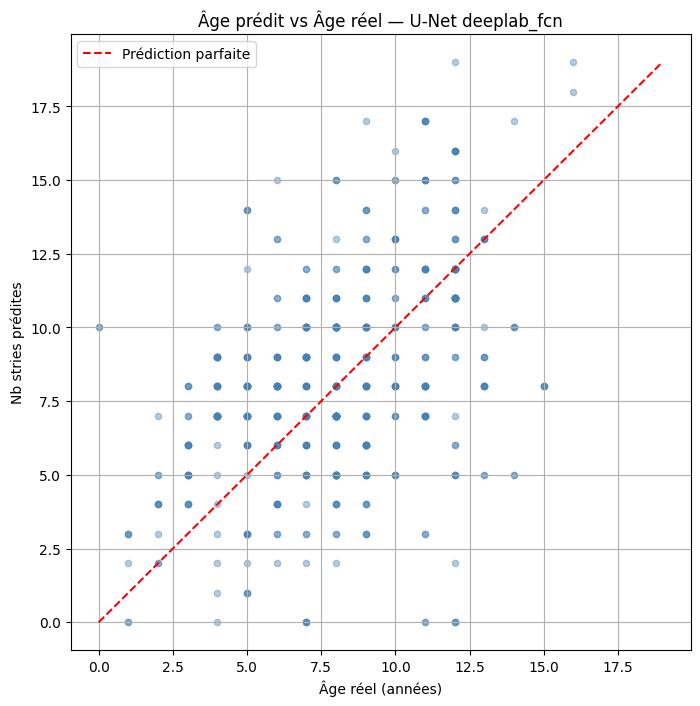

MAE finale : 2.72 ans


In [19]:
plt.figure(figsize=(8, 8))
plt.scatter(df_resultats['age_reel'], df_resultats['nb_stries'],
            alpha=0.4, s=20, color='steelblue')

# Ligne parfaite (prédit = réel)
max_age = max(df_resultats['age_reel'].max(), df_resultats['nb_stries'].max())
plt.plot([0, max_age], [0, max_age], 'r--', label='Prédiction parfaite')

plt.xlabel('Âge réel (années)')
plt.ylabel('Nb stries prédites')
plt.title('Âge prédit vs Âge réel — U-Net deeplab_fcn')
plt.legend()
plt.grid(True)
plt.show()

print(f"MAE finale : {df_resultats['erreur'].mean():.2f} ans")